## ***T1 - Optimization***

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [27]:
# Random Points Generation
rng = np.random.default_rng(42)
N = 20
coords = rng.integers(0, 101, size=(N, 3)).astype(float)  # shape (20, 3)

print("Generated 20 coordinates (x, y, z):")
print("  i |   x    y    z")
print("  --+----------------")
for i, (x, y, z) in enumerate(coords):
    print(f"  {i+1:2d}| {x:5.0f}{y:5.0f}{z:5.0f}")


Generated 20 coordinates (x, y, z):
  i |   x    y    z
  --+----------------
   1|     9   78   66
   2|    44   43   86
   3|     8   70   20
   4|     9   53   98
   5|    74   76   72
   6|    79   51   12
   7|    84   45   50
   8|    37   18   93
   9|    78   65   40
  10|    83   55   44
  11|    45   22    9
  12|    56   89    6
  13|    86   83   27
  14|    63   16   76
  15|    70   35    6
  16|    98   45   90
  17|    68   78   76
  18|    19   36   47
  19|    50    4   55
  20|    15   75   68


In [28]:
# Distance Matrix
def euclidean_dist_matrix(pts):
    """Build N×N Euclidean distance matrix."""
    n = len(pts)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            diff = pts[i] - pts[j]
            D[i, j] = np.sqrt(diff @ diff)
    return D

D = euclidean_dist_matrix(coords)


In [29]:
# Greedy Search
def greedy_tour(D):
    n = D.shape[0]
    visited = [False] * n
    tour = [0]
    visited[0] = True
    for _ in range(n - 1):
        last = tour[-1]
        nearest, min_d = -1, np.inf
        for j in range(n):
            if not visited[j] and D[last, j] < min_d:
                nearest, min_d = j, D[last, j]
        tour.append(nearest)
        visited[nearest] = True
    tour.append(0)   # return to start
    return tour

def tour_length(tour, D):
    return sum(D[tour[i], tour[i+1]] for i in range(len(tour)-1))

greedy = greedy_tour(D)
L_greedy = tour_length(greedy, D)
print(f"\nGreedy tour (1-indexed): {[t+1 for t in greedy]}")
print(f"Greedy tour length: {L_greedy:.4f}")


Greedy tour (1-indexed): [1, 20, 4, 2, 8, 14, 19, 18, 3, 12, 13, 9, 10, 7, 6, 15, 11, 5, 17, 16, 1]
Greedy tour length: 722.7952


In [30]:
# Simulated Annealing
def two_opt_swap(tour, i, k):
    """Reverse the segment tour[i..k]."""
    new_tour = tour[:i] + tour[i:k+1][::-1] + tour[k+1:]
    return new_tour

def simulated_annealing(D, init_tour, T0=5000.0, alpha=0.9995,
                        n_iter=100_000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n = D.shape[0]
    current = init_tour[:-1]          # working copy without closing node
    best = current[:]
    L_cur = tour_length(current + [current[0]], D)
    L_best = L_cur
    T = T0
    history = []

    for it in range(n_iter):
        # propose random 2-opt move
        i, k = sorted(rng.integers(1, n, size=2))
        if i == k:
            continue
        candidate = two_opt_swap(current, i, k)
        L_cand = tour_length(candidate + [candidate[0]], D)
        dE = L_cand - L_cur
        # Metropolis acceptance
        if dE < 0 or rng.random() < np.exp(-dE / T):
            current = candidate
            L_cur = L_cand
            if L_cur < L_best:
                best = current[:]
                L_best = L_cur
        T *= alpha
        if it % 10_000 == 0:
            history.append((it, L_cur, L_best, T))

    best_tour = best + [best[0]]
    return best_tour, L_best, history

sa_tour, L_sa, history = simulated_annealing(D, greedy[:], rng=rng)
print(f"\nSA optimized tour (1-indexed): {[t+1 for t in sa_tour]}")
print(f"SA tour length:     {L_sa:.4f}")
print(f"Improvement:        {(L_greedy - L_sa)/L_greedy*100:.2f}%")



SA optimized tour (1-indexed): [1, 3, 12, 13, 9, 5, 17, 16, 7, 10, 6, 15, 11, 18, 19, 14, 8, 2, 4, 20, 1]
SA tour length:     645.3072
Improvement:        10.72%


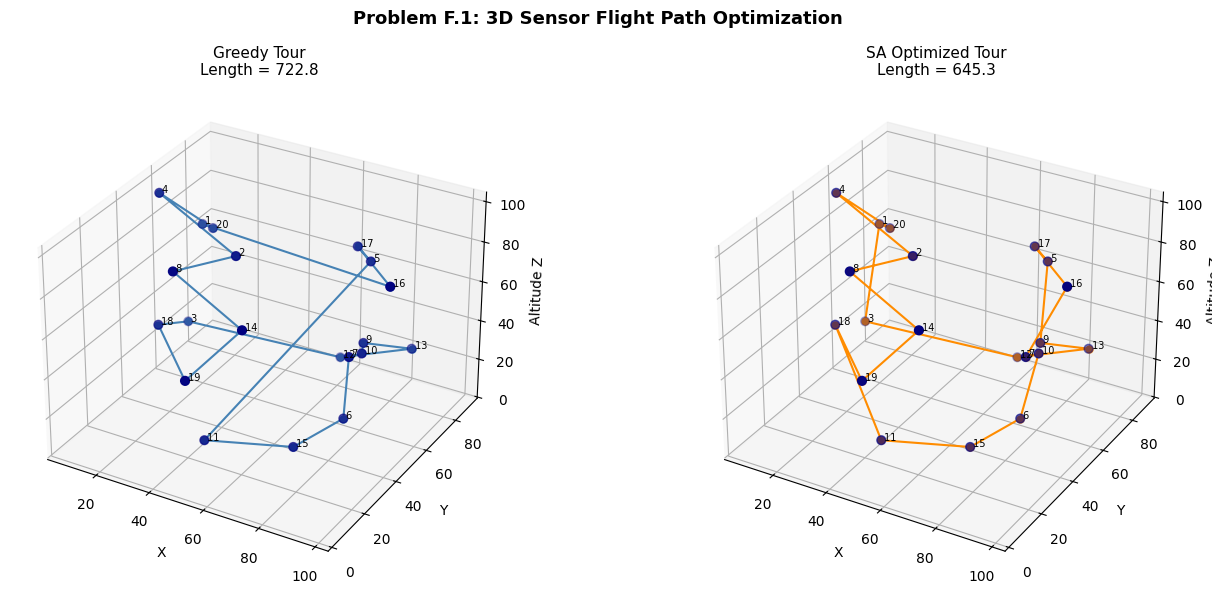

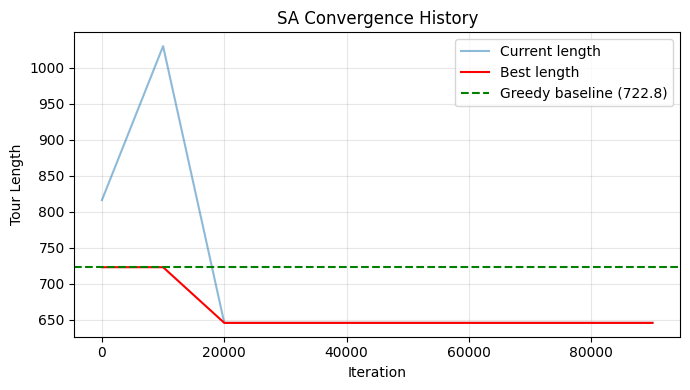


Plots saved.


In [31]:
# Visualization
fig = plt.figure(figsize=(14, 6))

# left: greedy tour
ax1 = fig.add_subplot(121, projection='3d')
gc = [coords[i] for i in greedy]
gx, gy, gz = zip(*gc)
ax1.plot(gx, gy, gz, 'o-', color='steelblue', linewidth=1.5, markersize=5)
ax1.scatter(*coords.T, c='navy', s=40, zorder=5)
for i, (x, y, z) in enumerate(coords):
    ax1.text(x, y, z, f' {i+1}', fontsize=7, color='black')
ax1.set_title(f'Greedy Tour\nLength = {L_greedy:.1f}', fontsize=11)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Altitude Z')

# right: SA tour
ax2 = fig.add_subplot(122, projection='3d')
sc = [coords[i] for i in sa_tour]
sx, sy, sz = zip(*sc)
ax2.plot(sx, sy, sz, 'o-', color='darkorange', linewidth=1.5, markersize=5)
ax2.scatter(*coords.T, c='navy', s=40, zorder=5)
for i, (x, y, z) in enumerate(coords):
    ax2.text(x, y, z, f' {i+1}', fontsize=7, color='black')
ax2.set_title(f'SA Optimized Tour\nLength = {L_sa:.1f}', fontsize=11)
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Altitude Z')

plt.suptitle('Problem F.1: 3D Sensor Flight Path Optimization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('f1_tours.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# convergence plot
iters, Lcur_hist, Lbest_hist, _ = zip(*history)
fig2, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, Lcur_hist, alpha=0.5, label='Current length')
ax.plot(iters, Lbest_hist, color='red', label='Best length')
ax.axhline(L_greedy, color='green', linestyle='--', label=f'Greedy baseline ({L_greedy:.1f})')
ax.set_xlabel('Iteration'); ax.set_ylabel('Tour Length')
ax.set_title('SA Convergence History')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.savefig('f1_convergence.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nPlots saved.")

## ***BVP***

In [32]:
# RK4
def rk4(f, t0, y0, tf, n):
    h = (tf - t0) / n
    t = np.linspace(t0, tf, n + 1)
    y = np.zeros((n + 1, len(y0)))
    y[0] = y0
    for i in range(n):
        ti, yi = t[i], y[i]
        k1 = h * f(ti, yi)
        k2 = h * f(ti + h/2, yi + k1/2)
        k3 = h * f(ti + h/2, yi + k2/2)
        k4 = h * f(ti + h,   yi + k3)
        y[i+1] = yi + (k1 + 2*k2 + 2*k3 + k4) / 6
    return t, y

# Driving force  g(t) = t^3 * e^{-t^2}
def g(t): return t**3 * np.exp(-t**2)

# BVP as system: u = [y, y'],  u' = [y', -4y + g(t)]
def F(t, u): return np.array([u[1], -4*u[0] + g(t)])

a, b = 0.0, 3.0
ya, yb = 0.0, 0.0

In [33]:
# Shooting Method
N = 100   # steps → 101 solution points

# IVP-1: y'(0) = 0
_, sol1 = rk4(F, a, np.array([ya, 0.0]), b, N)
y1_b = sol1[-1, 0]

# IVP-2: y'(0) = 1
_, sol2 = rk4(F, a, np.array([ya, 1.0]), b, N)
y2_b = sol2[-1, 0]

# Linear shooting formula
s = (yb - y1_b) / (y2_b - y1_b)
print(f"Shooting parameter  s = y'(0) = {s:.6f}")

t_s, sol_s = rk4(F, a, np.array([ya, s]), b, N)
y_s = sol_s[:, 0]
print(f"Boundary check y(3) = {y_s[-1]:.2e}  (should be ≈ 0)")

print(f"\n{'i':>4} {'t':>7} {'y_shoot':>14}")
print("-" * 28)
for i in range(0, N+1, 5):
    print(f"{i:4d} {t_s[i]:7.3f} {y_s[i]:14.8f}")

Shooting parameter  s = y'(0) = -0.290432
Boundary check y(3) = 6.94e-18  (should be ≈ 0)

   i       t        y_shoot
----------------------------
   0   0.000     0.00000000
   5   0.150    -0.04291057
  10   0.300    -0.08187982
  15   0.450    -0.11292970
  20   0.600    -0.13217925
  25   0.750    -0.13623064
  30   0.900    -0.12275578
  35   1.050    -0.09111857
  40   1.200    -0.04282461
  45   1.350     0.01836801
  50   1.500     0.08674321
  55   1.650     0.15527893
  60   1.800     0.21652450
  65   1.950     0.26353678
  70   2.100     0.29072233
  75   2.250     0.29447589
  80   2.400     0.27355735
  85   2.550     0.22919400
  90   2.700     0.16492629
  95   2.850     0.08623520
 100   3.000     0.00000000


In [34]:
# Finite Difference Method
dt = 0.1
t_f = np.arange(a, b + dt/2, dt)
n_int = len(t_f) - 2

c = -2.0 + 4.0 * dt**2

A = np.zeros((n_int, n_int))
rhs = np.zeros(n_int)
for i in range(n_int):
    A[i, i] = c
    if i > 0:       A[i, i-1] = 1.0
    if i < n_int-1: A[i, i+1] = 1.0
    rhs[i] = dt**2 * g(t_f[i+1])

y_int = np.linalg.solve(A, rhs)
y_f = np.zeros(len(t_f))
y_f[1:-1] = y_int

print(f"\n{'i':>3} {'t':>6} {'y_FDM':>14}")
print("-" * 26)
for i in range(len(t_f)):
    print(f"{i:3d} {t_f[i]:6.2f} {y_f[i]:14.8f}")


  i      t          y_FDM
--------------------------
  0   0.00     0.00000000
  1   0.10    -0.03070284
  2   0.20    -0.06016767
  3   0.30    -0.08714893
  4   0.40    -0.11039747
  5   0.50    -0.12868474
  6   0.60    -0.14085112
  7   0.70    -0.14587647
  8   0.80    -0.14296545
  9   0.90    -0.13163608
 10   1.00    -0.11179826
 11   1.10    -0.08380970
 12   1.20    -0.04849976
 13   1.30    -0.00715571
 14   1.40     0.03852846
 15   1.50     0.08653665
 16   1.60     0.13464060
 17   1.70     0.18052532
 18   1.80     0.22191949
 19   1.90     0.25672092
 20   2.00     0.28310900
 21   2.10     0.29963797
 22   2.20     0.30530711
 23   2.30     0.29960591
 24   2.40     0.28253391
 25   2.50     0.25459615
 26   2.60     0.21677619
 27   2.70     0.17048892
 28   2.80     0.11751640
 29   2.90     0.05992965
 30   3.00     0.00000000


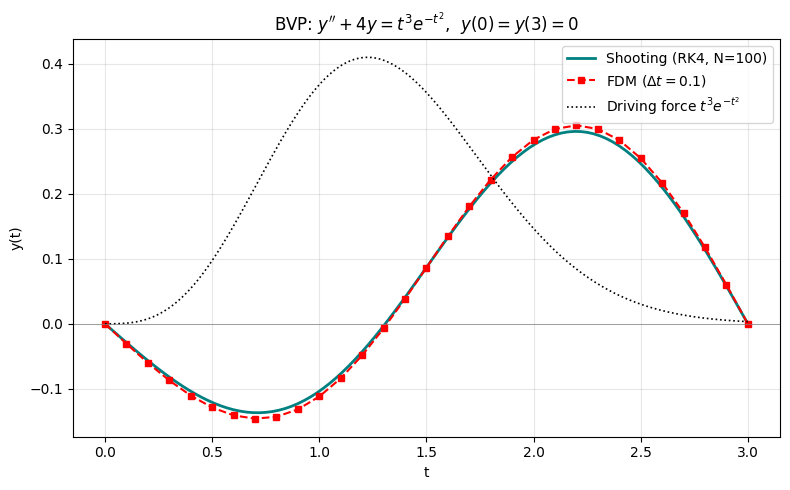

In [35]:
# Visualization
t_g = np.linspace(0, 3, 300)
plt.figure(figsize=(8, 5))
plt.plot(t_s, y_s, color='teal', lw=2,
         label='Shooting (RK4, N=100)')
plt.plot(t_f, y_f, 'rs--', ms=4, lw=1.5,
         label=r'FDM ($\Delta t=0.1$)')
plt.plot(t_g, g(t_g), 'k:', lw=1.2,
         label=r'Driving force $t^3 e^{-t^2}$')
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('t'); plt.ylabel('y(t)')
plt.title(r"BVP: $y''+4y=t^3e^{-t^2}$,  $y(0)=y(3)=0$")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## ***IVP & Interpolation & Curve Fitting***

In [20]:
from scipy.optimize import brentq


In [21]:
# Implicit RHS
def rhs(t, x):
    C = x**3 - 3.0 * np.exp(-t**3)
    return brentq(lambda u: np.exp(-u) - u - C, -50.0, 50.0, xtol=1e-12)


In [23]:
# RK4
t0, tf, N = 0.0, 5.0, 1000
h = (tf - t0) / N
t_arr = np.linspace(t0, tf, N + 1)
x_arr = np.zeros(N + 1); x_arr[0] = 1.0

for i in range(N):
    ti, xi = t_arr[i], x_arr[i]
    k1 = rhs(ti,       xi)
    k2 = rhs(ti + h/2, xi + h/2 * k1)
    k3 = rhs(ti + h/2, xi + h/2 * k2)
    k4 = rhs(ti + h,   xi + h   * k3)
    x_arr[i+1] = xi + h/6 * (k1 + 2*k2 + 2*k3 + k4)

print(f"x(0)={x_arr[0]:.4f}  x(1)={x_arr[N//5]:.6f}  x(5)={x_arr[-1]:.6f}")

x(0)=1.0000  x(1)=1.420604  x(5)=1.001090


In [24]:
# Newton Interpolation
t_nodes = np.array([0., 1., 2., 3., 4., 5.])
x_nodes = x_arr[(t_nodes / h).astype(int)]

print(f"\n{'t':>4} {'x(t)':>14}")
for tn, xn in zip(t_nodes, x_nodes):
    print(f"{tn:4.0f} {xn:14.8f}")

def newton_coeffs(xp, yp):
    """Compute divided difference coefficients."""
    d = yp.copy().astype(float)
    c = [d[0]]
    for j in range(1, len(xp)):
        d[j:] = (d[j:] - d[j-1:-1]) / (xp[j:] - xp[:len(xp)-j])
        c.append(d[j])
    return np.array(c)

def newton_eval(c, xp, t):
    """Evaluate Newton polynomial via Horner's scheme."""
    result = np.zeros_like(t, dtype=float)
    for k, tv in enumerate(t):
        val = c[-1]
        for j in range(len(c)-2, -1, -1):
            val = val * (tv - xp[j]) + c[j]
        result[k] = val
    return result

nd = newton_coeffs(t_nodes, x_nodes)
print(f"\nDivided difference coefficients:\n{nd}")

t_plot = np.linspace(0, 5, 500)
x_poly = newton_eval(nd, t_nodes, t_plot)



   t           x(t)
   0     1.00000000
   1     1.42060428
   2     1.10422480
   3     1.02218077
   4     1.00489683
   5     1.00109004

Divided difference coefficients:
[ 1.          0.42060428 -0.36849188  0.16188653 -0.04753727  0.01049322]


In [25]:
# Curve Fitting
t_fit = t_nodes[1:]
u_fit = (x_nodes[1:] - 1.0) / t_fit
mask  = u_fit > 0
tm, um = t_fit[mask], u_fit[mask]
Y  = np.log(um)
A  = np.column_stack([np.ones_like(tm), tm])
# Normal equations: A^T A c = A^T Y
c  = np.linalg.solve(A.T @ A, A.T @ Y)
alpha_fit = np.exp(c[0])
beta_fit  = -c[1]

print(f"\nFitted model: x(t) = 1 + {alpha_fit:.4f}·t·exp(-{beta_fit:.4f}·t)")
x_fit_plot  = 1.0 + alpha_fit * t_plot  * np.exp(-beta_fit * t_plot)
x_fit_nodes = 1.0 + alpha_fit * t_fit   * np.exp(-beta_fit * t_fit)
print(f"Residuals at nodes: {x_nodes[1:] - x_fit_nodes}")


Fitted model: x(t) = 1 + 2.4387·t·exp(-1.8881·t)
Residuals at nodes: [ 0.05147633 -0.0075177  -0.00318927 -0.00022318  0.00012134]


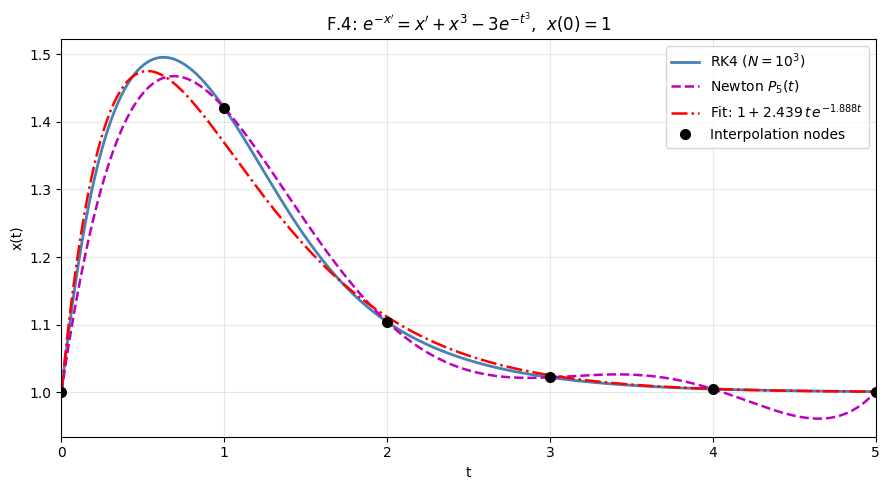

In [26]:
# Visualization
plt.figure(figsize=(9, 5))
plt.plot(t_arr,  x_arr,      color='steelblue', lw=2,
         label='RK4 ($N=10^3$)')
plt.plot(t_plot, x_poly,     'm--', lw=1.8,
         label='Newton $P_5(t)$')
plt.plot(t_plot, x_fit_plot, 'r-.', lw=1.8,
         label=rf'Fit: $1+{alpha_fit:.3f}\,t\,e^{{-{beta_fit:.3f}t}}$')
plt.plot(t_nodes, x_nodes,   'ko', ms=7, zorder=5,
         label='Interpolation nodes')
plt.xlabel('t'); plt.ylabel('x(t)')
plt.title(r"F.4: $e^{-x'}=x'+x^3-3e^{-t^3}$,  $x(0)=1$")
plt.legend(); plt.xlim(0, 5); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()